<a href="https://colab.research.google.com/github/adlihs/PyTorch/blob/main/A_Image_Classifier.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# An image classifier

## Imports

In [2]:
import numpy as np

import torch
import torch.nn as nn
import torch.optim as optim
import torchvision
import torchvision.transforms as transforms
from torch.utils.data import DataLoader
import matplotlib.pyplot as plt

#import helper_utils

## The code below selects the best available hardware to speed up the model training.

In [3]:
from torch.cuda import is_available
if torch.cuda.is_available():
  device = torch.device("cuda")
  print(f"Using device: CUDA")

elif torch.backends.mps.is_available():
  device = torch.device("mps")
  print(f"Using device: MPS")

else:
  device = torch.device("cpu")
  print(f"Using device: CPU")

Using device: CUDA


## **MNIST Dataset**: Preparing the data


*   Define `data_path` that specifies the folder where your dataset will be stored



In [4]:
# Set the path to store the dataset files
data_path = "./data"

##

*   Load the MNIST dataset using `torchvision.datasets.MNIST`.



In [5]:
train_dataset_without_transform = torchvision.datasets.MNIST(
    root = data_path, # Path to the directory where the data is/will be stored
    train = True, # Specify that you want the training split of the dataset
    download = True # Download the data if it's not found in the root directory
)

100%|██████████| 9.91M/9.91M [00:01<00:00, 5.10MB/s]
100%|██████████| 28.9k/28.9k [00:00<00:00, 134kB/s]
100%|██████████| 1.65M/1.65M [00:01<00:00, 1.26MB/s]
100%|██████████| 4.54k/4.54k [00:00<00:00, 13.2MB/s]


In [6]:
# Get the first sample (index 0), as a (image, label) tuple
image_pil, label = train_dataset_without_transform[0] # Get the first image

print(f"Image type:        {type(image_pil)}")
# Since `image_pil` is a PIL Image object, its dimensions are accessed using the .size attribute.
print(f"Image Dimensions:  {image_pil.size}")
print(f"Label Type:        {type(label)}")
print(f"Label value:       {label}")

Image type:        <class 'PIL.Image.Image'>
Image Dimensions:  (28, 28)
Label Type:        <class 'int'>
Label value:       5


## Visualizing a raw digit

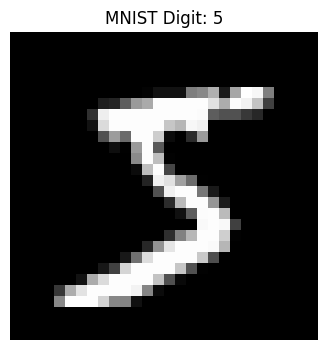

In [7]:
import matplotlib.pyplot as plt

# Convert the PIL Image to a NumPy array for matplotlib
image_np = np.array(image_pil)

# Display the image using matplotlib
plt.figure(figsize=(4, 4))
plt.imshow(image_np, cmap='gray')
plt.title(f'MNIST Digit: {label}')
plt.axis('off') # Hide axes ticks and labels
plt.show()

## **Transformations**
Let's use the `transforms.Compose` to chain together a sequence of preparation steps that are applied to each image as it's loaded.



*   `transforms.ToTensor():` Converts the PIL image into a PyTorch tensor and scales its pixel values from the original 0-255 range to values between 0 and 1.
*   `transforms.Normaliza():` Adjusts the tensor's values further by centering them around the zero, using the mean and standar deviation calculated from the MNIST dataset. This makes the data more consistent and helps the model learn faster and more reliability



In [8]:
# Convert images to tensors and normalize pixel values
# Pixel values are scaled to [0,1] and then standardized to mean 0 and std 1
transform = transforms.Compose([
    transforms.ToTensor(),
    transforms.Normalize((0.1307),(0.3081)) # MNIST meand and std
])

##
Now you'll load the dataset again, this time applying the transformations you just defined. The code is nearly identical to before, with one important addition.

* The `transform` argument is assigned the `transform` object you created earlier. This tells the `Dataset` to automatically apply your sequence of transformations (`ToTensor` and `Normalize`) to each image as it's loaded.

In [9]:
train_dataset = torchvision.datasets.MNIST(
    root = data_path, # Path to the directory where the data is/will be stored
    train = True, # Specify that want the training split of the dataset
    download = True, # Download the data if it's not found in the root directory
    transform = transform # Apply the defined transformations to each image
)

In [10]:
# Access the first item again
image_tensor, label = train_dataset[0]
print(f"Image Type:                   {type(image_tensor)}")
# Since the `image` is now a PyTorch Tensor, its dimensions are accessed using the .shape attribute.
print(f"Image Shape After Transform:  {image_tensor.shape}")
print(f"Label Type:                   {type(label)}")
print(f"Label value:                  {label}")

Image Type:                   <class 'torch.Tensor'>
Image Shape After Transform:  torch.Size([1, 28, 28])
Label Type:                   <class 'int'>
Label value:                  5


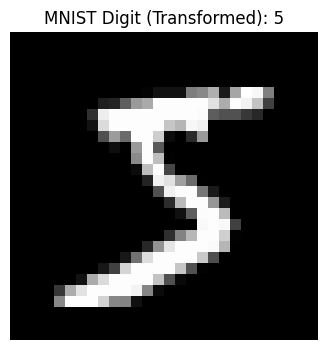

In [12]:
import matplotlib.pyplot as plt

# Convert the PyTorch tensor to a NumPy array and remove the channel dimension (squeeze)
image_np_transformed = image_tensor.squeeze().numpy()

# De-normalize the image for visualization
# Original normalization was: (x - mean) / std
# So, to reverse: x * std + mean
mean = 0.1307
std = 0.3081
image_np_denormalized = image_np_transformed * std + mean

# Display the image using matplotlib
plt.figure(figsize=(4, 4))
plt.imshow(image_np_denormalized, cmap='gray')
plt.title(f'MNIST Digit (Transformed): {label}')
plt.axis('off') # Hide axes ticks and labels
plt.show()

## Load the Test Dataset

In [13]:
test_dataset = torchvision.datasets.MNIST(
    root = data_path, # Path to the directory where the data is/will be stored
    train = False, # Specify that you want the testing split of the dataset
    download = True, # Download the data if it's not found in the root directory
    transform = transform # Apply the defined transformations to each image

)

## Create Data Loaders

A `DataLoader` takes the `Dataset` and serves it in manageable chunks called batches. This is essential for training on large datasets, as it avoids loading all the data into memory at once.

* **Training Loader**: For the training set, use a `batch_size` of 64 and set `shuffle=True.` Shuffling is critical during training because it randomizes the order of samples in each pass (epoch). This prevents the model from memorizing patterns in the dataset order and helps it generalize better.

* **Test Loader**: For the test set, you can use a much larger batch size (e.g., 1000) since gradients are not calculated during evaluation. This saves memory and speeds up testing. You'll set `shuffle=False` because the order of the data doesn't matter when you're only measuring the model's final performance.

In [15]:
# Create a data loader for the training set with shuffling enabled
train_loader = DataLoader(train_dataset, batch_size = 64, shuffle = True)

# Create a data loader for the test set with a larger batch size and no shuffling
test_loader = DataLoader(test_dataset, batch_size = 1000, shuffle=False)

## Building the Neural Network Model

The data pipeline complete, it's time to define the neural network's architecture. Let's create a custom model by creating a class that inherits from PyTorch's `nn.Module`. This pattern is flexible and gives you full control over the model’s structure.

Every `nn.Module` class has two essential parts:

* The `__init__` method is where it's define and initialize the layers the model will use, like gathering the tools before starting a job.
* The `forward` method is where it's define the exact path the data takes as it flows through those layers.

**Define the Model**

The model's architecture will include the following key components:

* `nn.Flatten()`: This layer's job is to transform the 2D image data (28x28 pixels) into a 1D vector of 784 elements (28 * 28 = 784). This reshaping step is required before passing the data into linear layers, which expect flat vectors rather than grids.

* `nn.Linear()`: These are the core layers of your network. The first linear layer will map the 784 input pixels to 128 hidden features, and the second will map those 128 features to 10 output classes, one for each digit class (0-9).

* `nn.ReLU()`: This is the activation function. It introduces non-linearity, enabling the model to learn complex patterns that simple linear transformations cannot capture.

In [16]:
class SimpleMNISTDNN(nn.Module):
  """
  A simple deep neural network model for the MNIST dataset.

  This model consists of a flatten layer followed by two linear layers
  with a ReLU activation function. It is designed for classification tasks
  on 28x28 grayscale images.
  """

  def __init__(self):
    """
    Initializes the layers of a neural network
    """

    super(SimpleMNISTDNN, self).__init__()
    # Initializes a layer to flatten the input tensor.
    # 28x28 input image to a 784-dimensional vector.
    self.flatten = nn.Flatten()

    # Initializes the sequential layers of the neural network
    self.layers = nn.Sequential(
        # Defines the first linear layer with 784 input features and 128 output features.
        nn.Linear(784, 128),

        # Applies the rectified linear unit activation function.
        nn.ReLU(),

        # Defines the second linear layer with 128 input features and 10 output features.
        nn.Linear(128,10)
    )

  def forward(self, x):
      """
        Defines the forward pass of the model.

        Args:
            x: The input tensor.

        Returns:
            The output tensor after passing through the network layers.
      """
      # Flattens the input tensor.
      x = self.flatten(x)
      # Passes the flattened tensor through the sequential layers
      x = self.layers(x)


## Training the Model

**Initialize Model, Loss Function, and Optimizer**

Before training, set up three essential components:

* **The Model:** First, you'll create an instance of the SimpleMNISTDNN class you defined earlier.

* As you saw in the lectures, it is essential for the model and the data to be on the same device to prevent errors. In this notebook, you'll handle this inside the training function itself. By moving both the model and the data to the `device` within that function, you guarantee they are correctly placed right before any computations happen.

* **The Loss Function:** You'll use `nn.CrossEntropyLoss` as your loss function. This is the standard choice for multi-class classification tasks like MNIST because it is specifically designed to measure the error when a model has to choose one class from several possibilities (i.e., one digit from 0-9).

* **The Optimizer:** You'll use `optim.Adam`, a popular and highly effective optimizer. The optimizer's job is to update the model's weights to minimize the loss. Adam is known for adapting the learning rate as it trains, which often helps the model learn more quickly and reliably than other optimizers.

In [17]:
# Initialize the neural network model
model = SimpleMNISTDNN()

# Define the loss function, suitable for multi-class classification
loss_function = nn.CrossEntropyLoss()

# Set Up the Adam optimizer to update the model's parameters with a learning rate of 0.001
optimizer = optim.Adam(model.parameters(), lr=0.001)

## Define the Training Function

This function encapsulates all the logic for a single training epoch, which is one full pass through the dataset. Each iteration over a single batch of data within that epoch is called a step. As a reminder, this function performs these key operations:

**Model Preparation**: Before iterating over the data, it prepares the model by moving it to the correct device and setting it to training mode with model.train().

**Core Training Loop**: For each batch of data, it executes the essential five-step training sequence: clearing gradients, running a forward pass, calculating loss, performing backpropagation, and updating the model's weights.

**Progress Reporting**: Finally, it tracks the running loss and accuracy, printing periodic updates to monitor how well the model is learning.

* Specifically, with 60,000 training images and a batch size of 64, the function will report its progress every 134 steps, giving you 7 consistent updates throughout the epoch.

In [ ]:
def train_epoch(model, loss_function, optimizer, train_loader, device):
  """
    Trains a PyTorch model for a single epoch.

    This function iterates over the training dataset, performs the forward and
    backward passes, and updates the model's weights. It also tracks and
    prints the loss and accuracy at specified intervals.

    Args:
        model: The neural network model to be trained.
        loss_function: The loss function used to calculate the error.
        optimizer: The optimizer used to update the model's weights.
        train_loader: The DataLoader providing batches of training data.
        device: The device (e.g., 'cuda' or 'cpu') on which to perform training.

    Returns:
        A tuple containing:
        - model: The model after training for one epoch.
        - avg_epoch_loss: The average loss calculated over all batches in the epoch.
    """

  # Ensure the model is on the current device for training
